# Exploratory Data Analysis (EDA)

### Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. V-Dem 
he Varieties of Democracy (V-Dem) dataset is a comprehensive political science dataset produced by the V-Dem Institute at the University of Gothenburg. It measures democratic attributes across 202 countries from 1789 to the present, covering over 500 indicators across five core democracy principles: electoral, liberal, participatory, deliberative, and egalitarian. This analysis uses the Country-Year Core edition (v16), which includes the primary democracy indices and regime classification variables.

Source: https://v-dem.net/data/the-v-dem-dataset/

In [4]:
df = pd.read_csv("data/V-Dem-CY-Core-v16.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
print(f"Countries: {df['country_name'].nunique()}")

Shape: (28092, 1908)
Years: 1789 – 2025
Countries: 202


The dataset contains 28,092 country-year observations across 202 countries spanning 1789–2025, with 1,908 attributes which provides the longitudinal depth needed to trace how academic freedom scores shift as regimes consolidate or lose power over time.

#### Dataset Overview

In [5]:
meta_cols = ["country_name", "country_text_id", "country_id", "year", "historical_date",
             "project", "historical", "histname", "COWcode"]
demo_indices = ["v2x_polyarchy", "v2x_libdem", "v2x_partipdem", "v2x_delibdem", "v2x_egaldem"]

print("Basic Info")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Countries: {df['country_name'].nunique()}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print()

print("Democracy Indices Summary (all years)")
display(df[demo_indices].describe().round(3))

Basic Info
Rows: 28,092
Columns: 1,908
Countries: 202
Year range: 1789 – 2025

Democracy Indices Summary (all years)


,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem
count,26954.000,25709.000,26341.000,19667.000,19667.000
mean,0.263,0.222,0.161,0.235,0.238
std,0.262,0.231,0.185,0.249,0.232
min,0.006,0.005,0.003,0.002,0.008
25%,0.056,0.058,0.030,0.040,0.064
50%,0.168,0.125,0.076,0.124,0.144
75%,0.374,0.297,0.226,0.375,0.341
max,0.922,0.896,0.808,0.887,0.885


##### Observations
- **Democracy is historically rare**
  - Median scores for all indices are well below 0.5  
  - Electoral democracy (v2x_polyarchy) median = **0.168**  
  - Most country-years fall under authoritarian or semi-authoritarian rule  

- **Bottom quartile = extreme repression**
  - 25th percentile ≈ **0.05–0.06** across indices  
  - ~25% of country-years had almost no democratic freedoms  
  - Strongly associated with aggressive education suppression  

- **Distributions are right-skewed**
  - 75th percentile ≈ **0.3–0.4**, max ≈ **0.9**  
  - Full democracies are rare outliers  
  - Most observations cluster on the authoritarian end  

- **Missing data is meaningful**
  - v2x_delibdem & v2x_egaldem: ~19,667 observations  
  - Other indices: ~26,000+ observations  
  - Indicates shorter historical coverage → note in methodology  

- **Use as benchmarks for case studies**
  - Global distributions provide context  
  - Cases like Germany (1933–45) or China (1966–76) fall well below historical averages  

In [6]:
cols = [
    # identifiers
    'country_name',
    'country_id', 
    'year',
    
    # primary variable
    'v2xca_academ', # academic freedom index
    
    # democracy indices (for context/comparison)
    'v2x_polyarchy', # electoral democracy
    'v2x_libdem', # liberal democracy
    'v2x_partipdem', # participatory democracy
    'v2x_delibdem', # deliberative democracy
    'v2x_egaldem', # egalitarian democracy
    
    # regime type (useful for labelling your six cases)
    'v2x_regime', # 0=closed autocracy, 1=electoral autocracy, 2=electoral democracy, 3=liberal democracy
]

df = df[cols]

# filter to the six countries focused for this case study
countries = ['Germany', 'Russia', 'Chile', 'China', 'Hungary', 'United States of America']
df_cases = df[df['country_name'].isin(countries)]

print(df_cases['country_name'].unique())  # verify spellings matched

<StringArray>
['Russia', 'United States of America', 'Chile', 'Germany', 'China', 'Hungary']
Length: 6, dtype: str


#### Regime Type Distribution

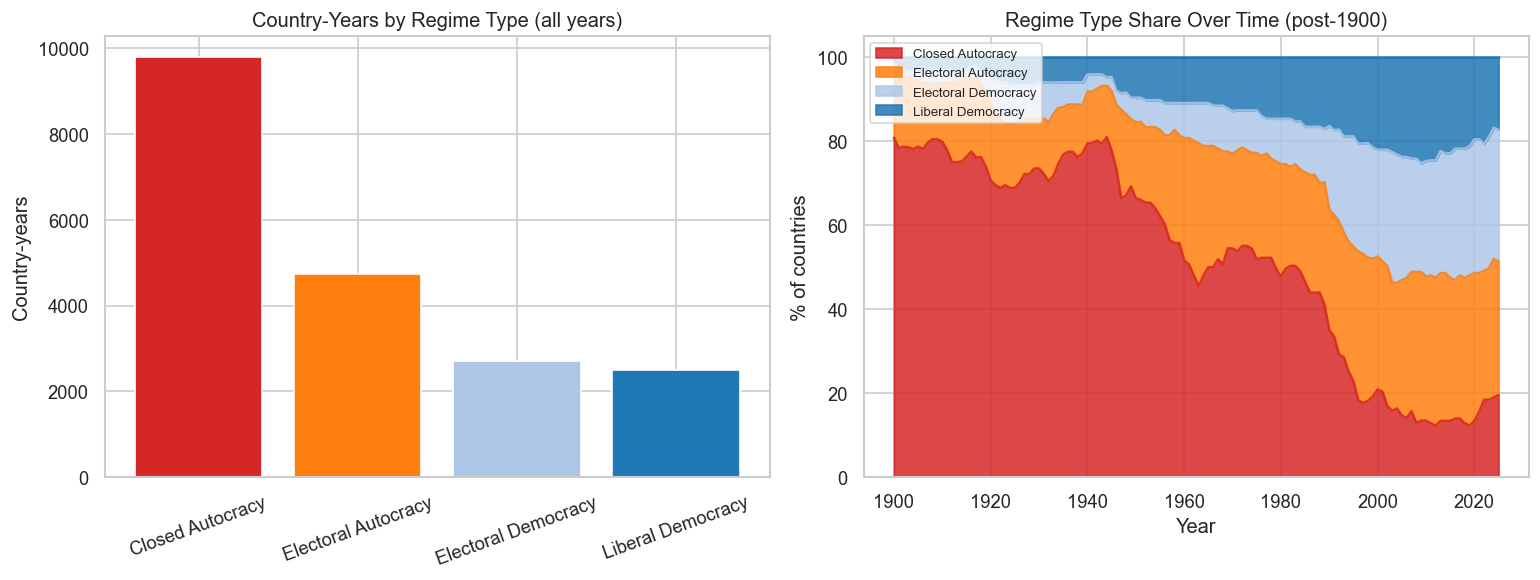

In [ ]:
regime_labels = {
    0: "Closed Autocracy",
    1: "Electoral Autocracy",
    2: "Electoral Democracy",
    3: "Liberal Democracy",
}
regime_colors = {
    "Closed Autocracy": "#d62728",
    "Electoral Autocracy": "#ff7f0e",
    "Electoral Democracy": "#aec7e8",
    "Liberal Democracy": "#1f77b4",
}

df["regime_label"] = df["v2x_regime"].map(regime_labels)

# overall count
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["regime_label"].value_counts().reindex(regime_labels.values())
axes[0].bar(counts.index, counts.values,
            color=[regime_colors[r] for r in counts.index])
axes[0].set_title("Country-Years by Regime Type (all years)")
axes[0].set_ylabel("Country-years")
axes[0].tick_params(axis="x", rotation=20)

# regime share over time (post-1900)
modern = df[df["year"] >= 1900].copy()
regime_time = (modern.groupby(["year", "regime_label"])
               .size().unstack(fill_value=0))
regime_time_pct = regime_time.div(regime_time.sum(axis=1), axis=0) * 100
regime_time_pct[list(regime_labels.values())].plot.area(
    ax=axes[1],
    color=[regime_colors[r] for r in regime_labels.values()],
    alpha=0.85
)
axes[1].set_title("Regime Type Share Over Time (post-1900)")
axes[1].set_ylabel("% of countries")
axes[1].set_xlabel("Year")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

##### Observations
- **Bar chart (overall distribution)**
  - **Closed autocracy dominates** (~10,000 country-years)  
  - **Liberal democracy is least common**  
  - Reinforces core idea where repression and control are historically typical, not exceptional  

- **Area chart (temporal trends)**
  - Reveals **three major eras** aligned with the proposed narrative  

  - **Pre-1945: Autocratic world**
    - Political systems overwhelmingly autocratic  
    - Context for cases like Germany and the USSR  

  - **1945–1990: Democratic expansion**
    - Decline of closed autocracy  
    - Rise of electoral autocracy and democracy  
    - Includes cases like Chile and its reversal under Pinochet  

  - **~2010–present: Democratic backsliding**
    - Growth of electoral autocracy (orange rising vs blue)  
    - Signals erosion of democratic norms  
    - Relevant to Hungary and emerging concerns in the US  

- **Narrative takeaway**
  - Historical pattern shows cycles, not linear progress  
  - Strengthens argument: control over knowledge persists across regime shifts  

### Democracy Indices - Distribution & Trends

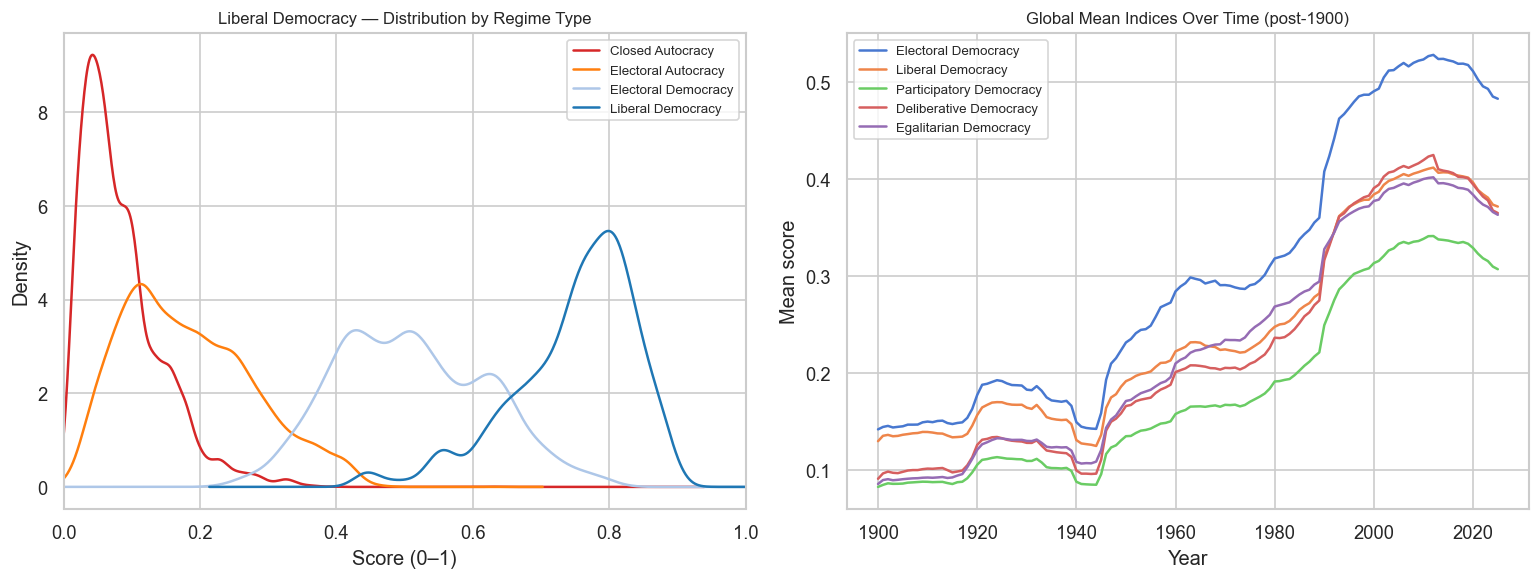

In [8]:
index_labels = {
    "v2x_polyarchy": "Electoral Democracy",
    "v2x_libdem": "Liberal Democracy",
    "v2x_partipdem": "Participatory Democracy",
    "v2x_delibdem": "Deliberative Democracy",
    "v2x_egaldem": "Egalitarian Democracy",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE for liberal democracy by regime
for rname, rcolor in regime_colors.items():
    subset = df[df["regime_label"] == rname]["v2x_libdem"].dropna()
    subset.plot.kde(ax=axes[0], label=rname, color=rcolor, linewidth=1.5)
axes[0].set_title("Liberal Democracy — Distribution by Regime Type", fontsize=10)
axes[0].set_xlabel("Score (0–1)")
axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=8)

# global mean over time
mean_over_time = df[df["year"] >= 1900].groupby("year")[list(index_labels.keys())].mean()
for col, label in index_labels.items():
    axes[1].plot(mean_over_time.index, mean_over_time[col], label=label, linewidth=1.5)
axes[1].set_title("Global Mean Indices Over Time (post-1900)", fontsize=10)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean score")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

##### Observations
- **KDE plot — liberal democracy by regime type**
  - Clear separation between closed autocracy (red) and liberal democracy (blue)
  - Closed autocracy is sharply concentrated near 0, confirming near-total absence of democratic freedoms  
  - Liberal democracy clusters tightly around 0.75–0.8, indicating a distinct ceiling for consolidated democracies  
  - Regime type is a strong predictor of liberal democracy scores, transitions into closed autocracy result in near-total collapse  

- **Electoral autocracy (orange curve)**
  - Peaks around 0.1–0.15, extending to ~0.35  
  - Represents regimes with democratic form but weak substance 
  - Ambiguity makes democratic erosion difficult to detect in real time
  - Includes contemporary cases such as Hungary and trends observed in the United States  

- **Electoral democracy (light blue curve)**
  - Broad, flat distribution across 0.2–0.6  
  - Reflects genuine variance with transitional or partially consolidated democracies  

- **Line chart (temporal trend)**
  - All indices rise sharply post-1945, with a visible dip around 1940 reflecting WWII-era democratic collapse  
  - Electoral democracy (blue) peaks highest (~0.52) around 2010–2012, followed by a sustained decline  
  - Other indices peak slightly later (~2012–2015) at ~0.4, then decline in parallel  
  - Participatory democracy (green) runs consistently lower across all periods  
  - Reflects a sustained global democratic reversal, not a short-term fluctuation  

- **Narrative significance**
  - Establishes a global baseline against which the six case countries can be positioned  
  - National-level declines (e.g., Hungary post-2010) align with a broader global pattern 
  - Reinforces the interpretation of democratic backsliding as a systemic, multi-dimensional trend

### Global Rank for the Six Case Countries

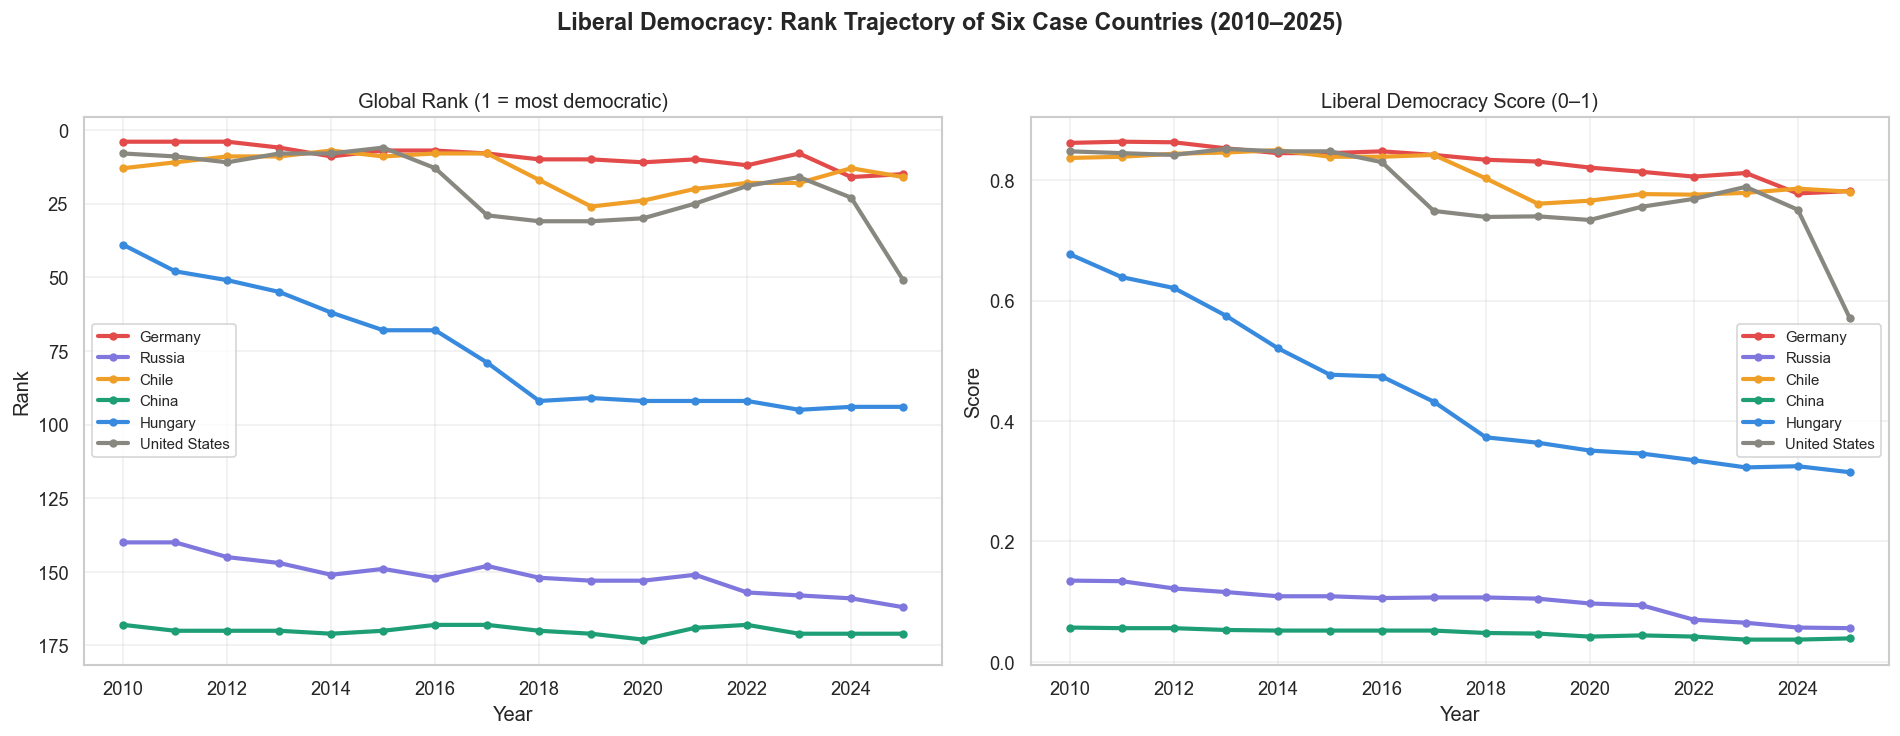


Rank Summary: 2010 vs 2025
-------------------------------------------------------
Germany                      4 →   15  (down 11 places)  score: 0.862 → 0.782
Russia                     140 →  162  (down 22 places)  score: 0.135 → 0.056
Chile                       13 →   16  (down 3 places)  score: 0.837 → 0.781
China                      168 →  171  (down 3 places)  score: 0.057 → 0.039
Hungary                     39 →   94  (down 55 places)  score: 0.677 → 0.315
United States                8 →   51  (down 43 places)  score: 0.848 → 0.571


In [ ]:
countries = ['Germany', 'Russia', 'Chile', 'China', 'Hungary', 'United States of America']
colors = {
    'Germany': '#E24B4A',
    'Russia': '#7F77DD',
    'Chile': '#EF9F27',
    'China': '#1D9E75',
    'Hungary': '#378ADD',
    'United States of America': '#888780'
}
labels = {
    'United States of America': 'United States'
}

# compute global rank per year on liberal democracy (ascending = worst rank 1)
df['rank'] = df.groupby('year')['v2x_libdem'] \
               .rank(ascending=False, method='min')
total_countries = df.groupby('year')['country_name'].count()

# filter to your six cases, post-2010
case_ranks = df[
    (df['country_name'].isin(countries)) &
    (df['year'] >= 2010)
][['country_name', 'year', 'rank', 'v2x_libdem']].copy()

# merge total country count per year to compute percentile
case_ranks = case_ranks.merge(total_countries.rename('total'), on='year')
case_ranks['percentile_rank'] = (case_ranks['rank'] / case_ranks['total']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Liberal Democracy: Rank Trajectory of Six Case Countries (2010–2025)',
             fontsize=14, fontweight='bold', y=1.02)

# left: raw rank (lower = better)
for country in countries:
    subset = case_ranks[case_ranks['country_name'] == country]
    label = labels.get(country, country)
    ax1.plot(subset['year'], subset['rank'],
             color=colors[country], linewidth=2.5, marker='o',
             markersize=4, label=label)

ax1.set_title('Global Rank (1 = most democratic)', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('Rank')
ax1.invert_yaxis()  # rank 1 at top
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# right: actual score over time
for country in countries:
    subset = case_ranks[case_ranks['country_name'] == country]
    label = labels.get(country, country)
    ax2.plot(subset['year'], subset['v2x_libdem'],
             color=colors[country], linewidth=2.5, marker='o',
             markersize=4, label=label)

ax2.set_title('Liberal Democracy Score (0–1)', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rank_trajectory_2010_2025.png', dpi=150, bbox_inches='tight')
plt.show()

# print a summary table
print("\nRank Summary: 2010 vs 2025")
for country in countries:
    subset = case_ranks[case_ranks['country_name'] == country]
    if subset.empty:
        continue
    r2010 = subset[subset['year'] == 2010]['rank'].values
    r2025 = subset[subset['year'] == 2025]['rank'].values
    s2010 = subset[subset['year'] == 2010]['v2x_libdem'].values
    s2025 = subset[subset['year'] == 2025]['v2x_libdem'].values
    if len(r2010) and len(r2025):
        change = int(r2025[0]) - int(r2010[0])
        direction = 'down' if change > 0 else 'up'
        label = labels.get(country, country)
        print(f"{label:<25} {int(r2010[0]):>4} → {int(r2025[0]):>4}  ({direction} {abs(change)} places)  score: {s2010[0]:.3f} → {s2025[0]:.3f}")

##### Observations
- Every case country declined — no country improved its liberal democracy rank between 2010 and 2025
- Hungary fell most sharply with its rank dropping from 39 &rarr; 94 (−55 places); score nearly halved from 0.677 &rarr; 0.315, the steepest proportional collapse among the six
- United States dropped from 8 &rarr; 51 (−43 places); score fell from 0.848 → 0.571, a significant slide for an established democracy
- Germany and Chile held the top tier with both declining modestly and remain in the global top 20 with scores above 0.78
- Russia and China were already near the floor - minimal rank movement because there was little room left to fall; both scored below 0.06 in 2025

### Correlation Matrix of Democracy Indices

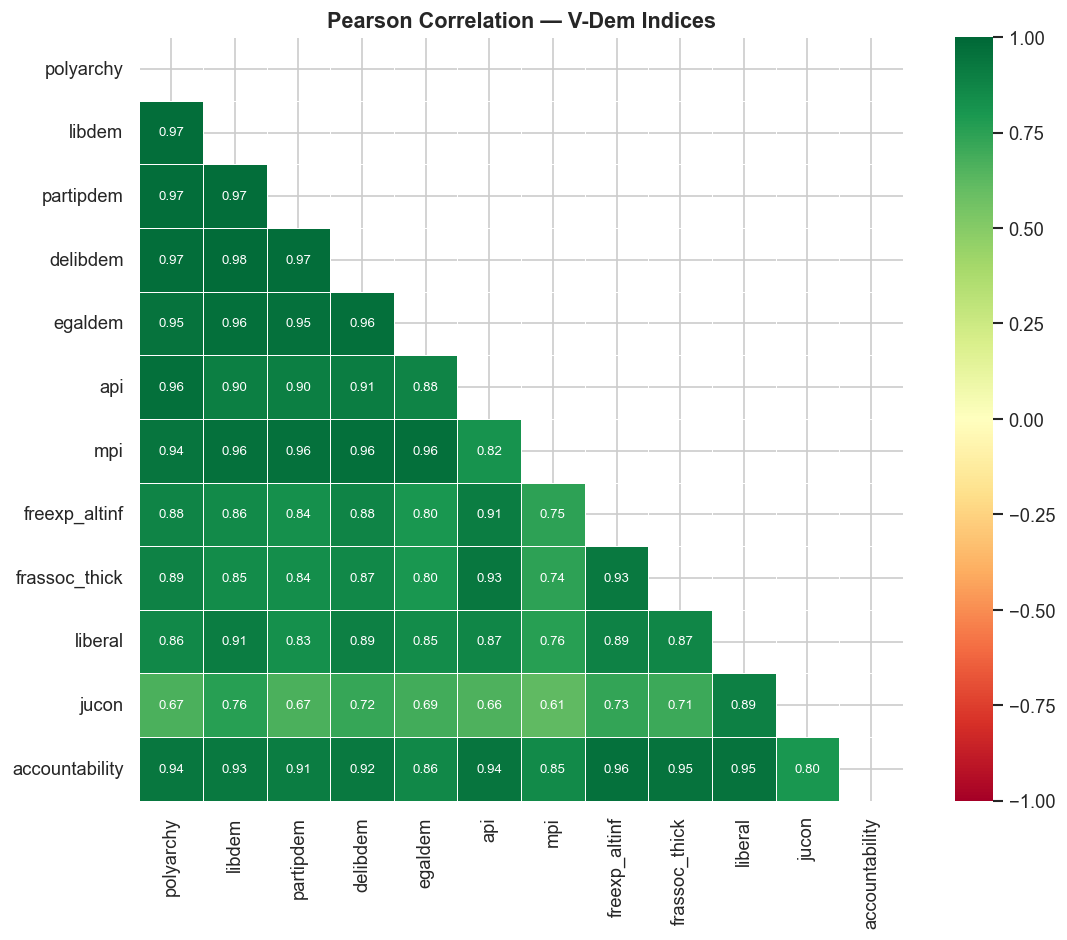

In [10]:
# loading extra columns from the original file
extra_cols = [
    'country_name', 'year',
    'v2x_api', 'v2x_mpi', 'v2x_freexp_altinf',
    'v2x_frassoc_thick', 'v2x_liberal', 'v2x_jucon',
    'v2x_accountability'
]

df_extra = pd.read_csv('data/V-Dem-CY-Core-v16.csv', usecols=extra_cols)

# merge with existing cut-down df (left join to keep rows intact) 
df_corr = df.merge(df_extra, on=['country_name', 'year'], how='left')

# define indices — only what now exists in df_corr
extended_indices = [
    'v2x_polyarchy', 'v2x_libdem', 'v2x_partipdem', 'v2x_delibdem', 'v2x_egaldem',
    'v2x_api', 'v2x_mpi', 'v2x_freexp_altinf', 'v2x_frassoc_thick',
    'v2x_liberal', 'v2x_jucon', 'v2x_accountability'
]

# safety check — drops any that still didn't load
available_indices = [c for c in extended_indices if c in df_corr.columns]
missing = [c for c in extended_indices if c not in df_corr.columns]
if missing:
    print(f"Still missing, dropped from heatmap: {missing}")

# compute correlation 
extended_labels = [c.replace('v2x_', '') for c in available_indices]

corr = df_corr[available_indices].corr()
corr.index = extended_labels
corr.columns = extended_labels

# plot
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation — V-Dem Indices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vdem_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observations
- **High correlation across all indices**
  - Correlations range from 0.61 to 0.98
  - No negative or weak relationships  
  - All indices move strongly together 
  - Decline in one dimension (e.g., electoral democracy) is matched by declines across others  

- **Interpretation**
  - Democratic dimensions are interdependent, not independent variables
  - Erosion occurs as a system-wide process, not in isolated areas  
  - Drops in democracy coincide with declines in:
    - Freedom of expression (~0.88+)  
    - Freedom of association (~0.89+)  
    - Judicial independence (~0.67+)  

- **Core implication**
  - Suppression of academic freedom is part of a broader coordinated erosion  
  - Restrictions on knowledge production align with wider institutional decline  
  - Supports the idea that control mechanisms operate holistically across systems

- **Notable exception**
  - Judicial constraints (jucon) show weaker correlations (0.61–0.76)  
  - Judiciary tends to be more resilient or slower to decline
  - Suggests a sequencing effect:
    - Media, academic, and associational freedoms weaken first  
    - Judicial institutions erode later  

- **Analytical takeaway**
  - Democratic backsliding is multi-dimensional and synchronized
  - Institutional collapse follows identifiable patterns rather than random variation  

### Democratic Backsliding — Change in Polyarchy Score (2010-2025)

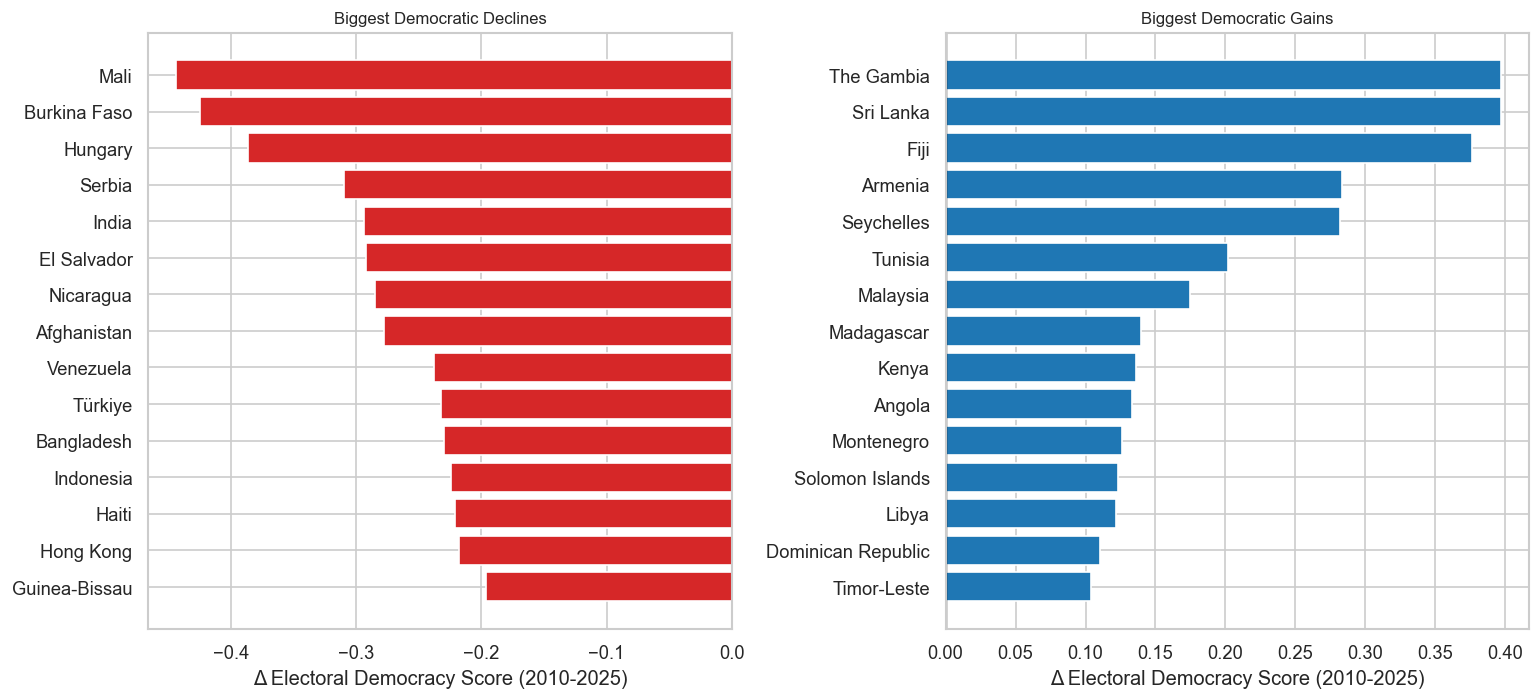

In [11]:
base_year = 2010
score_col = "v2x_polyarchy"

base = df[df["year"] == base_year][["country_name", score_col]].rename(columns={score_col: "score_2010"})
curr = df[df["year"] == latest_year][["country_name", score_col]].rename(columns={score_col: "score_latest"})
change = base.merge(curr, on="country_name").dropna()
change["delta"] = change["score_latest"] - change["score_2010"]

biggest_decline  = change.nsmallest(15, "delta")
biggest_increase = change.nlargest(15, "delta")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

def delta_bar(ax, data, title):
    colors = ["#d62728" if d < 0 else "#1f77b4" for d in data["delta"]]
    ax.barh(data["country_name"], data["delta"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Δ Electoral Democracy Score ({base_year}-{latest_year})")
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

delta_bar(axes[0], biggest_decline,  "Biggest Democratic Declines")
delta_bar(axes[1], biggest_increase, "Biggest Democratic Gains")

plt.tight_layout()
plt.show()

##### Observations
- **Hungary as a top global decliner**
  - Ranked among the largest democratic declines since 2010
  - Comparable to countries like Mali and Burkina Faso (military coups)  
  - Distinction: decline occurred through legal and electoral mechanisms, not force  
  - Widely identified as a leading case of rapid autocratisation (German Marshall Fund, 2022)

- **Key contrast**
  - Mali & Burkina Faso &rarr; sudden collapse via coups
  - Hungary &rarr; gradual institutional capture (laws, media, courts, universities)  
  - Outcome converges despite different pathways  

- **Other notable decliners**
  - India** &rarr; large-scale democratic erosion in a major democracy  
  - Turkey, Hong Kong, Nicaragua, Venezuela have a similar trajectory:
    - Centralisation of executive power  
    - Weakening of checks and balances  
    - Targeting of media, judiciary, and education systems  

- **United States: a differentiated pattern**
  - Absent from top electoral democracy decliners  
  - Indicates slower erosion of electoral mechanisms
  - However, significant decline in liberal dimensions (rights, rule of law)  

- **Democratic “gainers” pattern**
  - Gains concentrated in:
    - Smaller states  
    - Previously authoritarian regimes  
    - Low baseline starting points  
  - No evidence of improvement among established democracies 

- **Overall interpretation**
  - Democratic gains appear fragile and incremental
  - Democratic declines are structural and large-scale  
  - Hungary exemplifies a global pattern, not an isolated anomaly  

## 2. Banned Books
The PEN America Index of School Book Bans tracks books banned or removed from US school libraries and classrooms. This dataset covers **July 2021 – June 2022**, the first full academic year of widespread organised book-banning in the United States.

Source: https://pen.org/book-bans/banned-book-list-2021-2022/

In [11]:
df_books = pd.read_csv("data/banned-book-list.csv")

# parse dates — format is "Mon-YY"
df_books["date"] = pd.to_datetime(df_books["Date of Challenge/Removal"], format="%b-%y")

print(f"Shape: {df_books.shape}")
print(f"Period: {df_books['date'].min().strftime('%b %Y')} – {df_books['date'].max().strftime('%b %Y')}")
print(f"Unique titles: {df_books['Title'].nunique()}")
print(f"States affected: {df_books['State'].nunique()}")
print(f"Districts affected: {df_books['District'].nunique()}")
print()
print("Origin of challenge:")
print(df_books["Origin of Challenge"].value_counts().to_string())

Shape: (2532, 11)
Period: Jul 2021 – Jun 2022
Unique titles: 1648
States affected: 32
Districts affected: 138

Origin of challenge:
Origin of Challenge
Administrator       2383
Formal Challenge     143
Other                  6


##### Observations
- 2,532 bans across 32 states and 5,894 unique titles in a single academic year
- 94% of bans initiated by administrators, not by community formal challenges revealing that this is institutionally driven, not grassroots
- Bans are concentrated: Texas, Florida, and Pennsylvania alone account for ~72% of all bans

#### Ban Type & Geographic Distribution

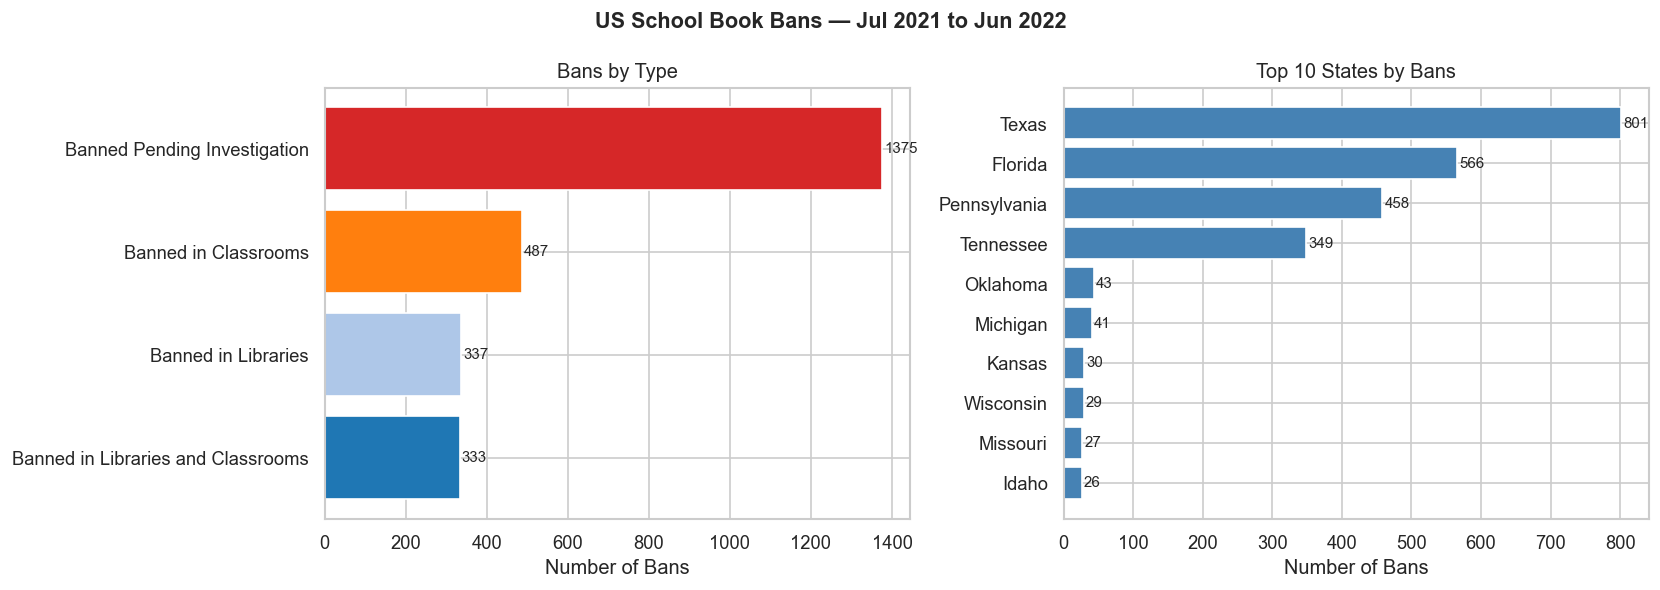

In [12]:
ban_colors = {
    "Banned Pending Investigation": "#d62728",
    "Banned in Classrooms": "#ff7f0e",
    "Banned in Libraries": "#aec7e8",
    "Banned in Libraries and Classrooms": "#1f77b4",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ban type breakdown
ban_counts = df_books["Type of Ban"].value_counts()
axes[0].barh(
    ban_counts.index,
    ban_counts.values,
    color=[ban_colors[b] for b in ban_counts.index]
)
axes[0].set_xlabel("Number of Bans")
axes[0].set_title("Bans by Type")
axes[0].invert_yaxis()
for i, v in enumerate(ban_counts.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

# top 10 states
state_counts = df_books["State"].value_counts().head(10)
axes[1].barh(state_counts.index, state_counts.values, color="steelblue")
axes[1].set_xlabel("Number of Bans")
axes[1].set_title("Top 10 States by Bans")
axes[1].invert_yaxis()
for i, v in enumerate(state_counts.values):
    axes[1].text(v + 3, i, str(v), va="center", fontsize=9)

plt.suptitle("US School Book Bans — Jul 2021 to Jun 2022", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("banned_books_type_state.png", dpi=150, bbox_inches="tight")
plt.show()

##### Observations
- "Banned Pending Investigation" (54%) is the dominant type meaning that books are removed pre-emptively before any formal review, indicating reactive institutional control
- Classroom bans (19%) outnumber library bans (13%) showing that the primary target is instructional content, not just access
- Texas and Florida alone account for 54% of all bans, indicating policy and political context drive the phenomenon, not broad public demand

#### Bans Over Time (Monthly)

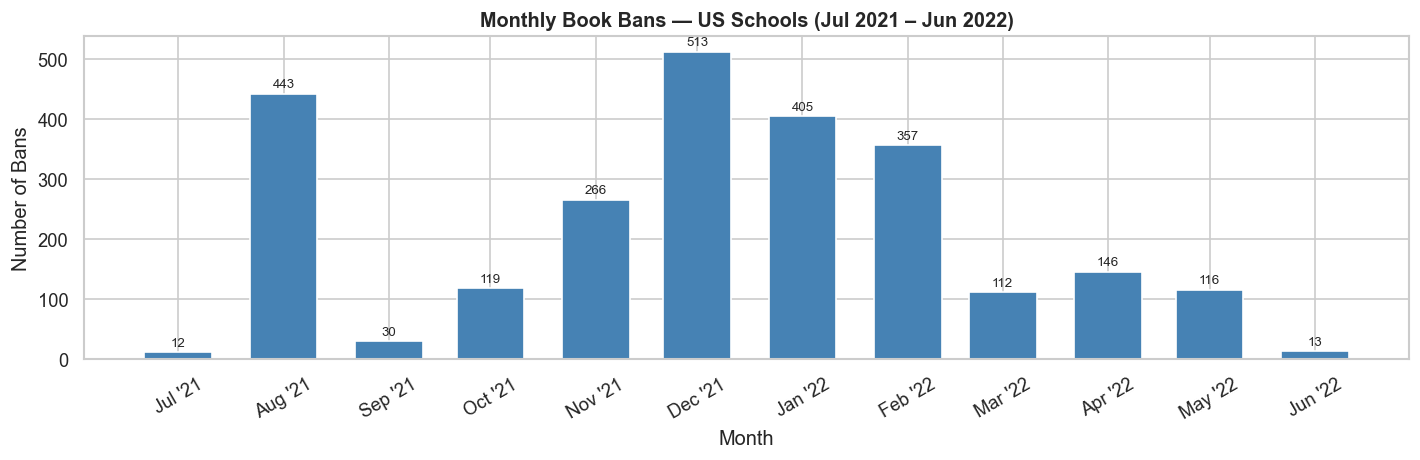

In [ ]:
# Count bans per month
monthly = df_books.groupby("date").size().reset_index(name="bans")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly["date"], monthly["bans"], width=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Bans")
ax.set_title("Monthly Book Bans — US Schools (Jul 2021 – Jun 2022)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: pd.Timestamp.fromordinal(int(x)).strftime("%b '%y") if x > 0 else ""
))
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xticks(rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("banned_books_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

##### Observations
- Bans surged sharply in Jan–Apr 2022, coinciding with Florida's HB 1467 (signed 25 March 2022) and an administrative push in Texas following Rep. Krause's October 2021 letter requesting removal of 850 titles.
- The spike is policy-driven, not organic as the timing aligns precisely with new laws requiring districts to audit and remove books pending review
- Early months (Jul–Oct 2021) show low activity, confirming this is an emergent, accelerating phenomenon rather than a long-standing baseline

## 3. Book Ban By State
The previous dataset revealed Texas and Florida account for approximately half of all book bans. To examine whether bans concentrate in politically aligned states, we incorporate state-level 2020 presidential vote shares from MIT Election Data and Science Lab (2023) as a proxy for political leaning.

Source: https://electionlab.mit.edu/data

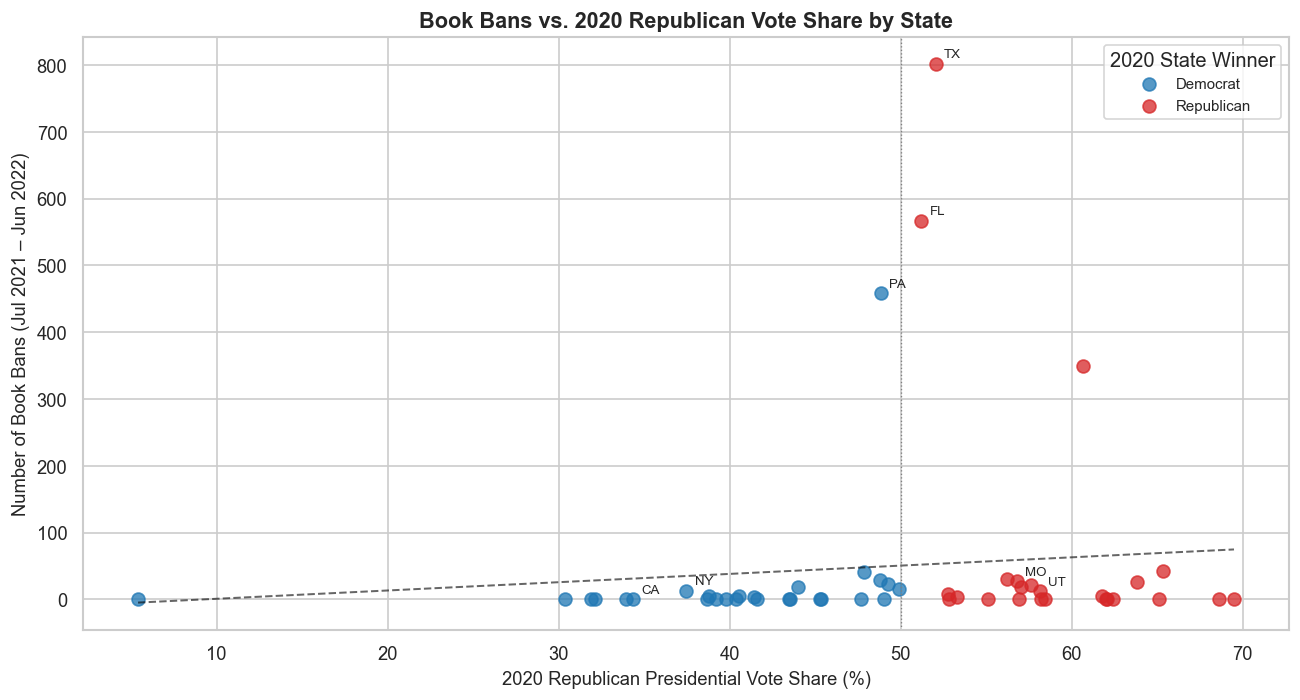

Correlation (GOP share vs bans): 0.097

 state_title state_po  gop_share  bans      party
       Texas       TX  52.057604 801.0 Republican
     Florida       FL  51.219820 566.0 Republican
Pennsylvania       PA  48.843612 458.0   Democrat
   Tennessee       TN  60.660294 349.0 Republican
    Oklahoma       OK  65.373272  43.0 Republican
    Michigan       MI  47.837291  41.0   Democrat
      Kansas       KS  56.212513  30.0 Republican
   Wisconsin       WI  48.822437  29.0   Democrat
    Missouri       MO  56.799656  27.0 Republican
       Idaho       ID  63.837565  26.0 Republican


In [ ]:
# 2020 Republican vote share by state 
df_elect = pd.read_csv("data/1976-2020-president.csv")
df_2020 = df_elect[df_elect["year"] == 2020].copy()

rep = df_2020[df_2020["party_simplified"] == "REPUBLICAN"][["state", "state_po", "candidatevotes", "totalvotes"]]
rep = rep.copy()
rep["gop_share"] = rep["candidatevotes"] / rep["totalvotes"] * 100
rep["state_title"] = rep["state"].str.title()

# book bans by state
bans_by_state = df_books["State"].value_counts().reset_index()
bans_by_state.columns = ["state_title", "bans"]

# merge
merged = rep.merge(bans_by_state, on="state_title", how="left")
merged["bans"] = merged["bans"].fillna(0)
merged["party"] = merged["gop_share"].apply(lambda x: "Republican" if x >= 50 else "Democrat")

# scatter: GOP share vs bans 
fig, ax = plt.subplots(figsize=(11, 6))

colors = {"Republican": "#d62728", "Democrat": "#1f77b4"}
for party, group in merged.groupby("party"):
    ax.scatter(group["gop_share"], group["bans"],
               color=colors[party], alpha=0.75, s=60, label=party)

# regression line
m, b = np.polyfit(merged["gop_share"], merged["bans"], 1)
x_line = np.linspace(merged["gop_share"].min(), merged["gop_share"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2, linestyle="--", alpha=0.6)

# label notable states
label_states = {"Texas", "Florida", "Pennsylvania", "Missouri", "Utah", "California", "New York"}
for _, row in merged.iterrows():
    if row["state_title"] in label_states:
        ax.annotate(row["state_po"], (row["gop_share"], row["bans"]),
                    textcoords="offset points", xytext=(5, 4), fontsize=8)

ax.axvline(50, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("2020 Republican Presidential Vote Share (%)", fontsize=11)
ax.set_ylabel("Number of Book Bans (Jul 2021 – Jun 2022)", fontsize=11)
ax.set_title("Book Bans vs. 2020 Republican Vote Share by State", fontsize=13, fontweight="bold")
ax.legend(title="2020 State Winner", fontsize=9)
plt.tight_layout()
plt.savefig("bookbans_vs_gop_share.png", dpi=150, bbox_inches="tight")
plt.show()

# summary table
print(f"Correlation (GOP share vs bans): {merged['gop_share'].corr(merged['bans']):.3f}")
print()
print(merged[["state_title", "state_po", "gop_share", "bans", "party"]]
      .sort_values("bans", ascending=False)
      .head(10)
      .to_string(index=False))

##### Observations
- Correlation is near zero (r = 0.097), indicating that  Republican vote share alone does not predict book bans; being a deeply red state does not mean more bans
- Texas and Florida are legislative outliers, not partisan outliers — both voted only marginally Republican (~51–52% in 2020) yet account for over half of all national bans; the driver is specific state legislation (Florida HB 1467; Texas Rep. Krause's removal directive), not electorate intensity
- Deeply Republican states cluster near zero with Idaho, Utah, Oklahoma, and Kansas (60–70% GOP) recording very few bans, confirming that partisan lean alone does not trigger banning activity
- Pennsylvania breaks the partisan frame, it was voted Democrat in 2020 yet ranked 3rd nationally (458 bans), driven by Republican-controlled school districts operating independently of the state-level political outcome
- The mechanism is legislative, not electoral -  banning is concentrated where governors and legislatures passed book-audit laws that forced mass pre-emptive administrative removals; this aligns with the earlier finding that 94% of bans are administrator-initiated, not community-driven

Overall, partisan lean is a necessary but not sufficient condition as targeted policy action in two states, not broad ideological geography, explains the national pattern.

## 4. USA Department of Education Quarterly Spending
This dataset tracks total federal obligations issued by the US Department of Education across fiscal quarters from FY2017 to FY2026, sourced from USASpending.gov. The US federal fiscal year runs October–September (Q1: Oct–Dec, Q2: Jan–Mar, Q3: Apr–Jun, Q4: Jul–Sep). Obligations represent funds legally committed to be spent, not disbursements.

Source: [USASpending.gov — Results Over Time by Quarter](https://www.usaspending.gov/search)

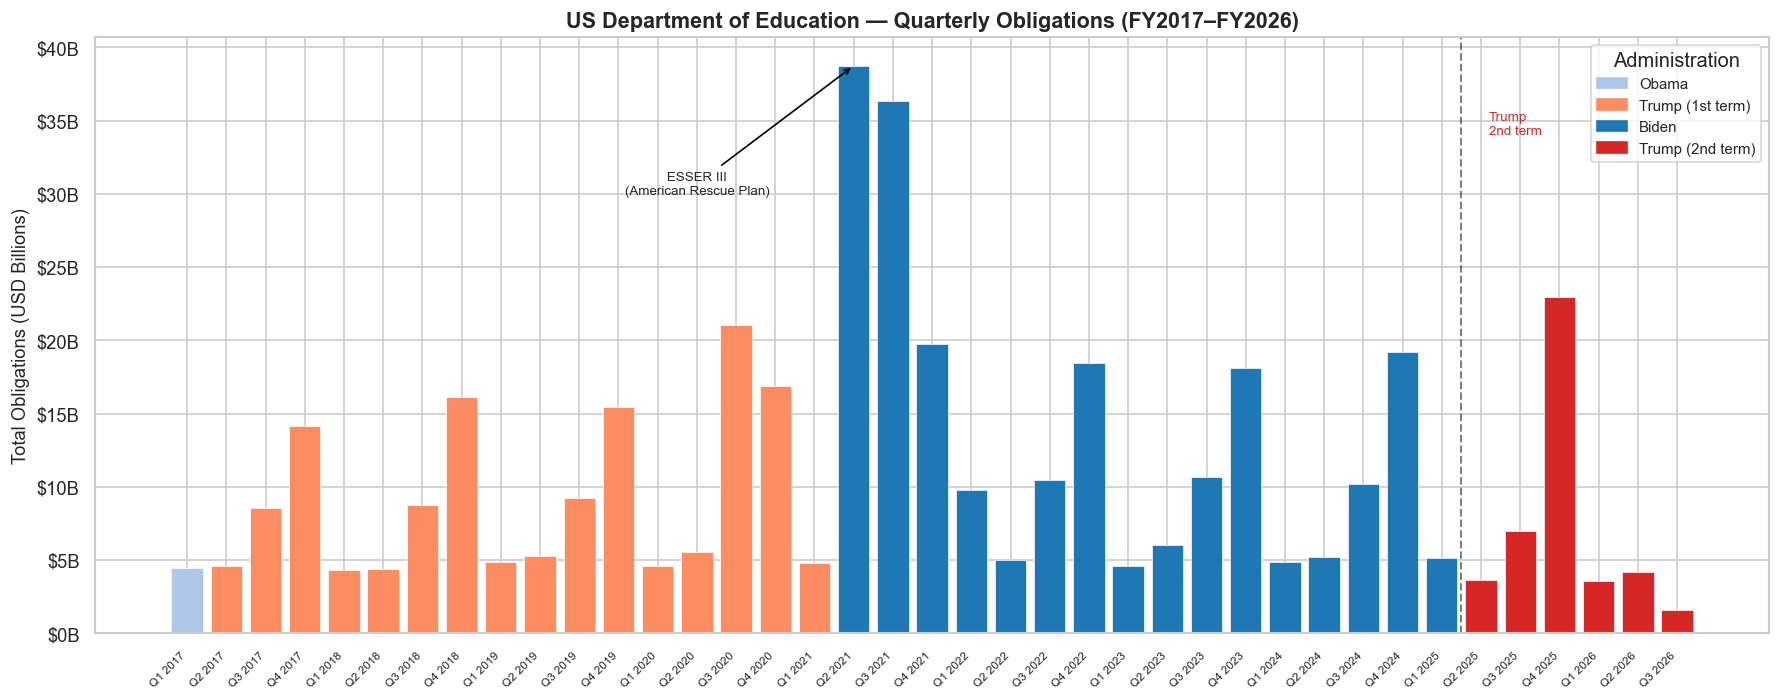

Year-over-year change — same quarter (FY2024 vs FY2025)
----------------------------------------------------
  Q1: $4.84B → $5.13B  (+6.1%)
  Q2: $5.19B → $3.65B  (-29.6%)
  Q3: $10.21B → $7.02B  (-31.3%)
  Q4: $19.20B → $22.93B  (+19.4%)


In [ ]:
df_edu = pd.read_csv("data/results-over-time-by-quarter-1777527703100.csv")

# parse and sort chronologically
df_edu[["q", "yr"]] = df_edu["fiscal_quarter"].str.split(" ", expand=True)
df_edu["yr"] = df_edu["yr"].astype(int)
df_edu["q_num"] = df_edu["q"].str[1].astype(int)
df_edu = df_edu.sort_values(["yr", "q_num"]).reset_index(drop=True)
df_edu["obligations_bn"] = df_edu["total_obligations"] / 1e9

# drop Q4 2026 (zero — incomplete period)
df_edu = df_edu[df_edu["total_obligations"] > 0].reset_index(drop=True)

# label each quarter by administration (based on inauguration dates)
def get_era(q_num, yr):
    if yr < 2017 or (yr == 2017 and q_num == 1):
        return "Obama"
    elif yr < 2021 or (yr == 2021 and q_num == 1):
        return "Trump (1st term)"
    elif yr < 2025 or (yr == 2025 and q_num == 1):
        return "Biden"
    else:
        return "Trump (2nd term)"

df_edu["era"] = df_edu.apply(lambda r: get_era(r["q_num"], r["yr"]), axis=1)

era_colors = {
    "Obama":           "#aec7e8",
    "Trump (1st term)":"#fc8d62",
    "Biden":           "#1f77b4",
    "Trump (2nd term)":"#d62728",
}

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    range(len(df_edu)),
    df_edu["obligations_bn"],
    color=[era_colors[e] for e in df_edu["era"]],
    edgecolor="white", linewidth=0.4
)

ax.set_xticks(range(len(df_edu)))
ax.set_xticklabels(df_edu["fiscal_quarter"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Total Obligations (USD Billions)", fontsize=11)
ax.set_title("US Department of Education — Quarterly Obligations (FY2017–FY2026)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))

# legend
handles = [mpatches.Patch(color=c, label=l) for l, c in era_colors.items()]
ax.legend(handles=handles, fontsize=9, title="Administration")

# annotate ESSER III peak
esser_idx = df_edu[df_edu["fiscal_quarter"] == "Q2 2021"].index[0]
ax.annotate("ESSER III\n(American Rescue Plan)",
            xy=(esser_idx, df_edu.loc[esser_idx, "obligations_bn"]),
            xytext=(esser_idx - 4, 30),
            fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", color="black", lw=1))

# mark Trump 2nd term start
trump2_idx = df_edu[df_edu["fiscal_quarter"] == "Q2 2025"].index[0]
ax.axvline(trump2_idx - 0.5, color="black", linewidth=1.2, linestyle="--", alpha=0.5)
ax.text(trump2_idx + 0.2, df_edu["obligations_bn"].max() * 0.88,
        "Trump\n2nd term", fontsize=8, color="#d62728")

plt.tight_layout()
plt.savefig("edu_spending_quarterly.png", dpi=150, bbox_inches="tight")
plt.show()

# YoY same-quarter comparison: 2024 vs 2025
print("Year-over-year change — same quarter (FY2024 vs FY2025)")
for q in ["Q1", "Q2", "Q3", "Q4"]:
    r24 = df_edu[df_edu["fiscal_quarter"] == f"{q} 2024"]["obligations_bn"].values
    r25 = df_edu[df_edu["fiscal_quarter"] == f"{q} 2025"]["obligations_bn"].values
    if len(r24) and len(r25):
        pct = (r25[0] - r24[0]) / r24[0] * 100
        print(f"  {q}: ${r24[0]:.2f}B → ${r25[0]:.2f}B  ({pct:+.1f}%)")

##### Observations
- 2021 ESSER III spike is an outlier, not a baseline with Q2 2021 ($38.7B) and Q3 2021 ($36.3B) reflect one-time COVID relief obligations under the Elementary and Secondary School Emergency Relief Fund (ESSER III), appropriated through the American Rescue Plan Act (2021). The U.S. Government Accountability Office (GAO, 2024) confirmed the temporary nature of these funds, noting that state officials explicitly warned districts against spending that "could not be sustained after ESSER funds ended" (p. 1); pre- and post-2021 spending levels are therefore structurally different and should not be compared directly
- Q4 spikes are a recurring structural pattern, not a policy signal, the highest-spending quarter every year is Q4 (Jul–Sep), driven by "use it or lose it" end-of-fiscal-year obligation deadlines that apply across all administrations; Liebman & Mahoney (2017) found that federal spending in the final week of the fiscal year is 4.9 times higher than the weekly average for the rest of the year, confirming this is an institutional budget mechanic rather than a directional policy choice
- Trump 1st term showed steady growth with obligations rising gradually from ~$14B (Q4 2017) to ~$16B (Q4 2020), consistent with normal annual budget increases
- Trump 2nd term shows a clear contraction in mid-year quarters as Q2 2025 ($3.65B) and Q3 2025 ($7.02B) are down 30% and 31% respectively from the same quarters in 2024, coinciding with DOGE-led restructuring that eliminated over 1,300 DOE positions (nearly half the agency's workforce) and cancelled approximately $900 million in research contracts by March 2025 (NPR, 2025)
- FY2026 accelerates the decline with Q3 2026 ($1.57B) being the lowest non-zero quarter in the entire dataset, suggesting further structural contraction as funding freezes and programme eliminations take hold

**Narrative significance**

The 2025–2026 contraction is distinct from COVID-era volatility; it reflects a deliberate withdrawal from federal education obligations and provides quantitative grounding for the US case study on institutional erosion

# References
German Marshall Fund. (2022). *The erosion of democracy and rule of law in Hungary*. https://www.gmfus.org/news/erosion-democracy-and-rule-law-hungary

Liebman, J. B., & Mahoney, N. (2017). Do expiring budgets lead to wasteful year-end spending? Evidence from federal procurement. *American Economic Review*, *107*(11), 3510–3549. https://doi.org/10.1257/aer.20131296

MIT Election Data and Science Lab. (2023). *U.S. President 1976–2020* [Data set]. Harvard Dataverse. https://doi.org/10.7910/DVN/42MVDX

NPR. (2025, March 12). *The Education Department is being cut in half. Here's what's being lost*. https://www.npr.org/2025/03/12/nx-s1-5325854/trump-education-department-layoffs-civil-rights-student-loans

PEN America. (2022). *Banned book list* [Data set]. https://pen.org/book-bans/banned-book-list-2021-2022/

U.S. Government Accountability Office. (2024). *K-12 education: School districts reported spending initial COVID relief funds on meeting students' needs and continuing school operations* (Report No. GAO-24-106913). https://www.gao.gov/products/gao-24-106913